Upload: models_catalog.csv, pricing_history.csv, capability_milestones.csv, compute_estimates.csv, benchmark_scores.csv


Saving benchmark_scores.csv to benchmark_scores.csv
Saving capability_milestones.csv to capability_milestones.csv
Saving compute_estimates.csv to compute_estimates.csv
Saving models_catalog.csv to models_catalog.csv
Saving pricing_history.csv to pricing_history.csv
Models: (113, 13)
Pricing: (1187, 5)
Milestones: (57, 13)
Compute: (113, 11)
Benchmarks: (1276, 9)

models: missing=0, duplicates=0

pricing: missing=0, duplicates=0

milestones: missing=0, duplicates=0

compute: missing=0, duplicates=0

benchmarks: missing=0, duplicates=0
Master shape after merging compute: (113, 20)
Models with outlier training cost: 22
           model_name  training_cost_usd_est
105           GPT-5.5               20982857
98              GPT-5               18214285
99                 o5                4196571
45        GPT-4 Turbo                3902976
27              GPT-4                3902976
85   LLaMA 4 Behemoth                3085714
81            GPT-4.5                2468571
107            G

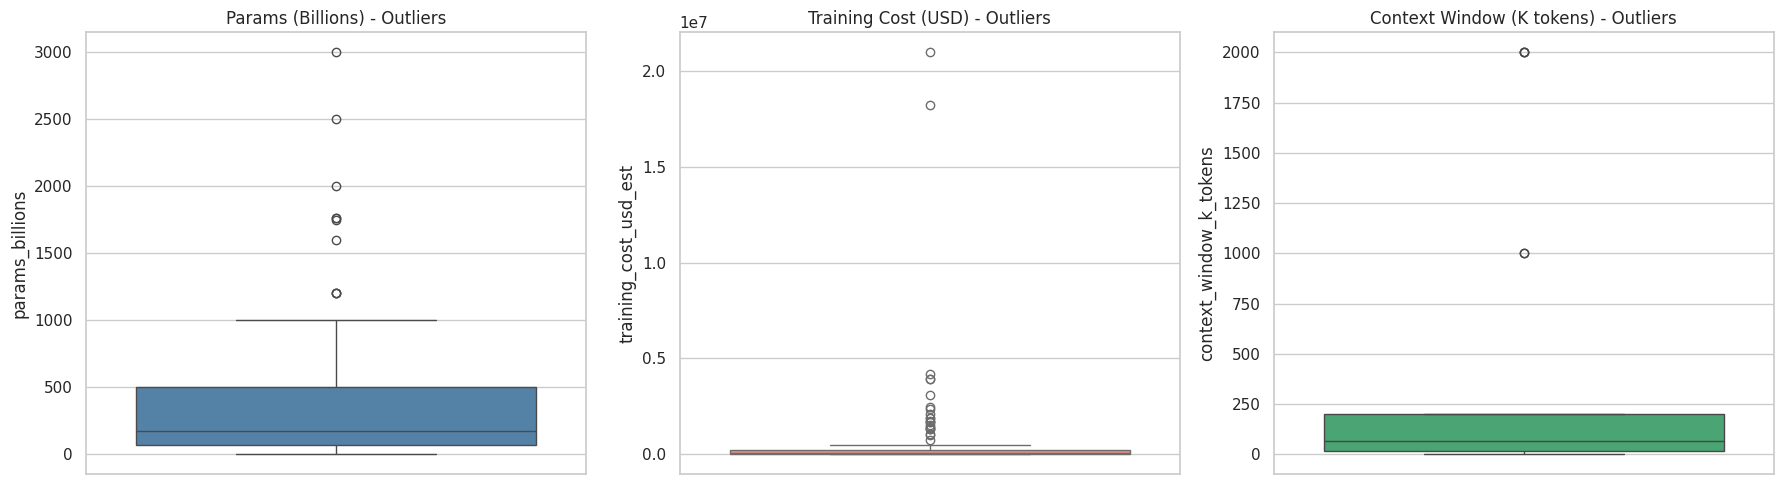

/tmp/ipykernel_1154/1565783119.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=models, x='release_year', palette='viridis')


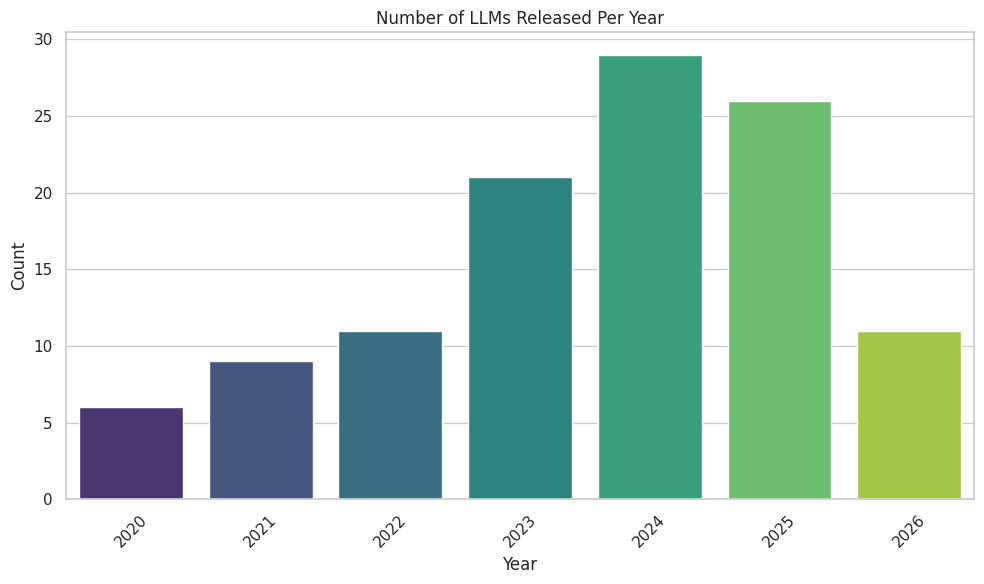

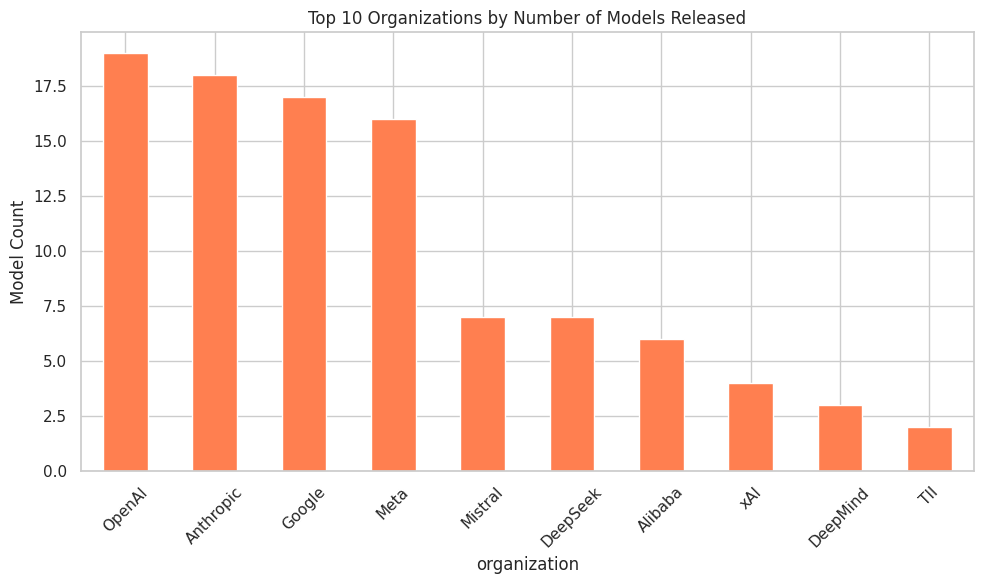

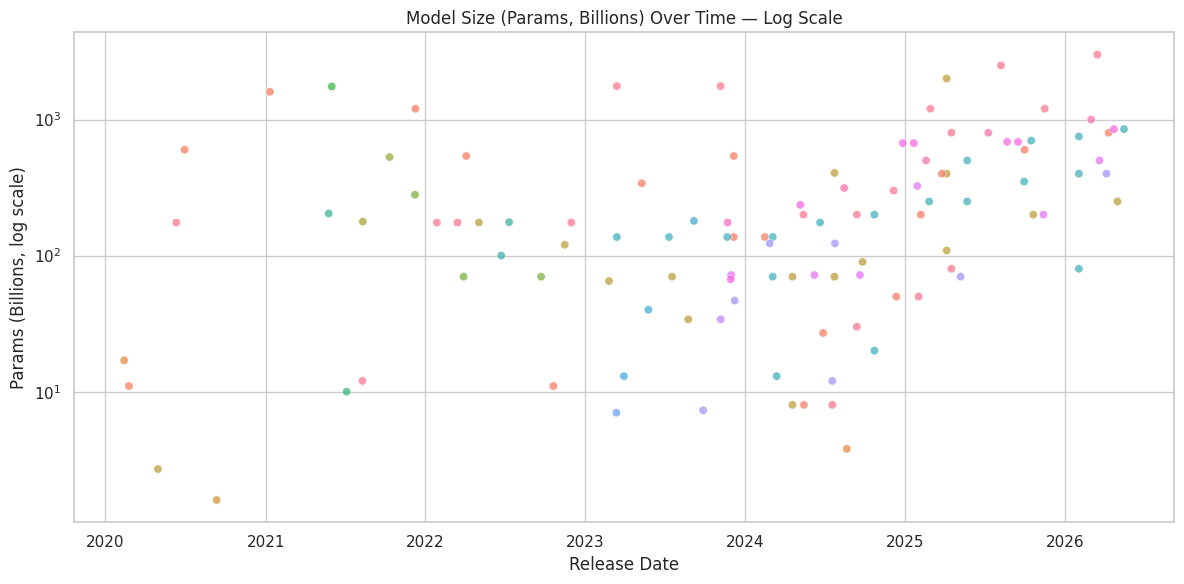

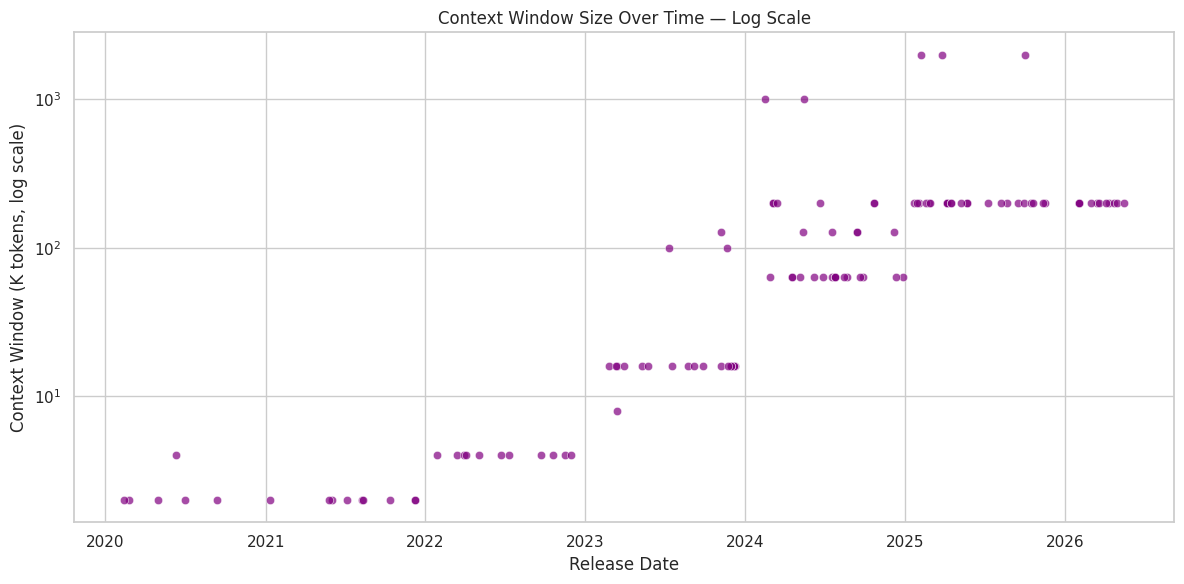

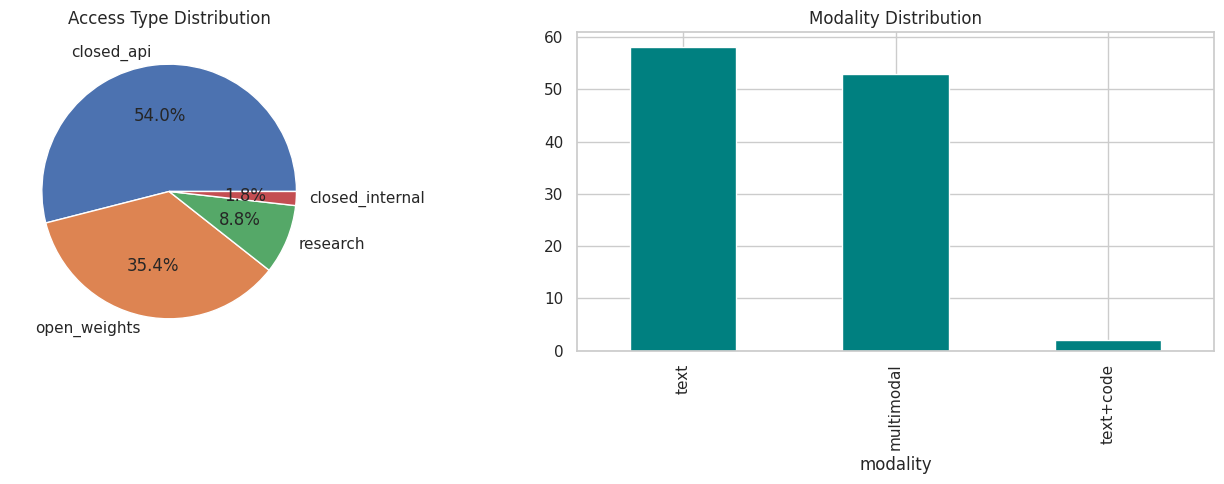

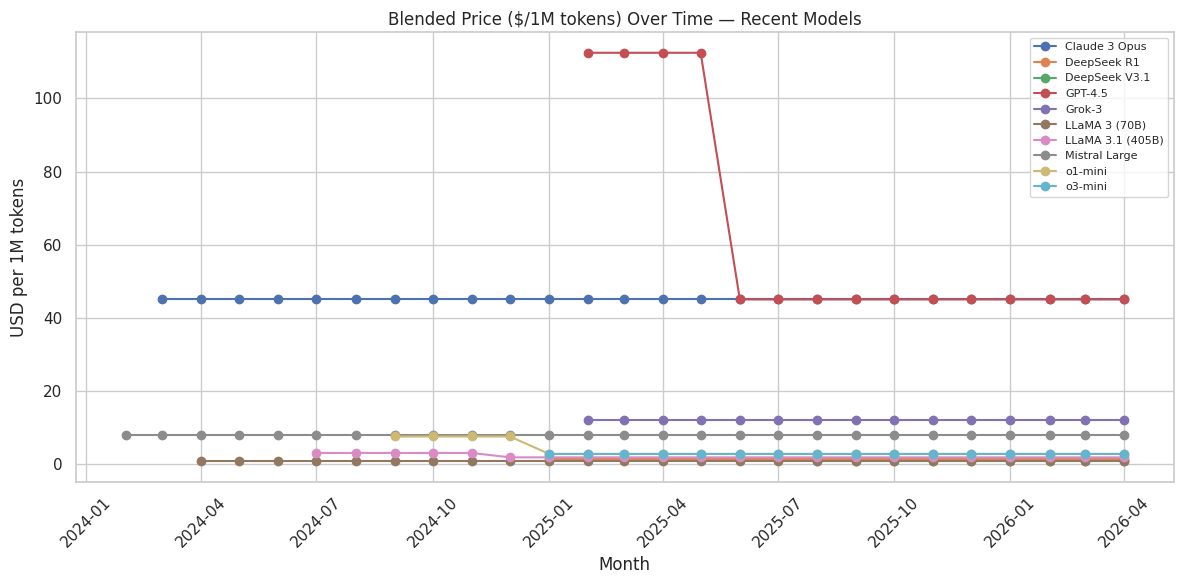

/tmp/ipykernel_1154/1565783119.py:160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=models, x='release_year', ax=axes[0, 0], palette='viridis')


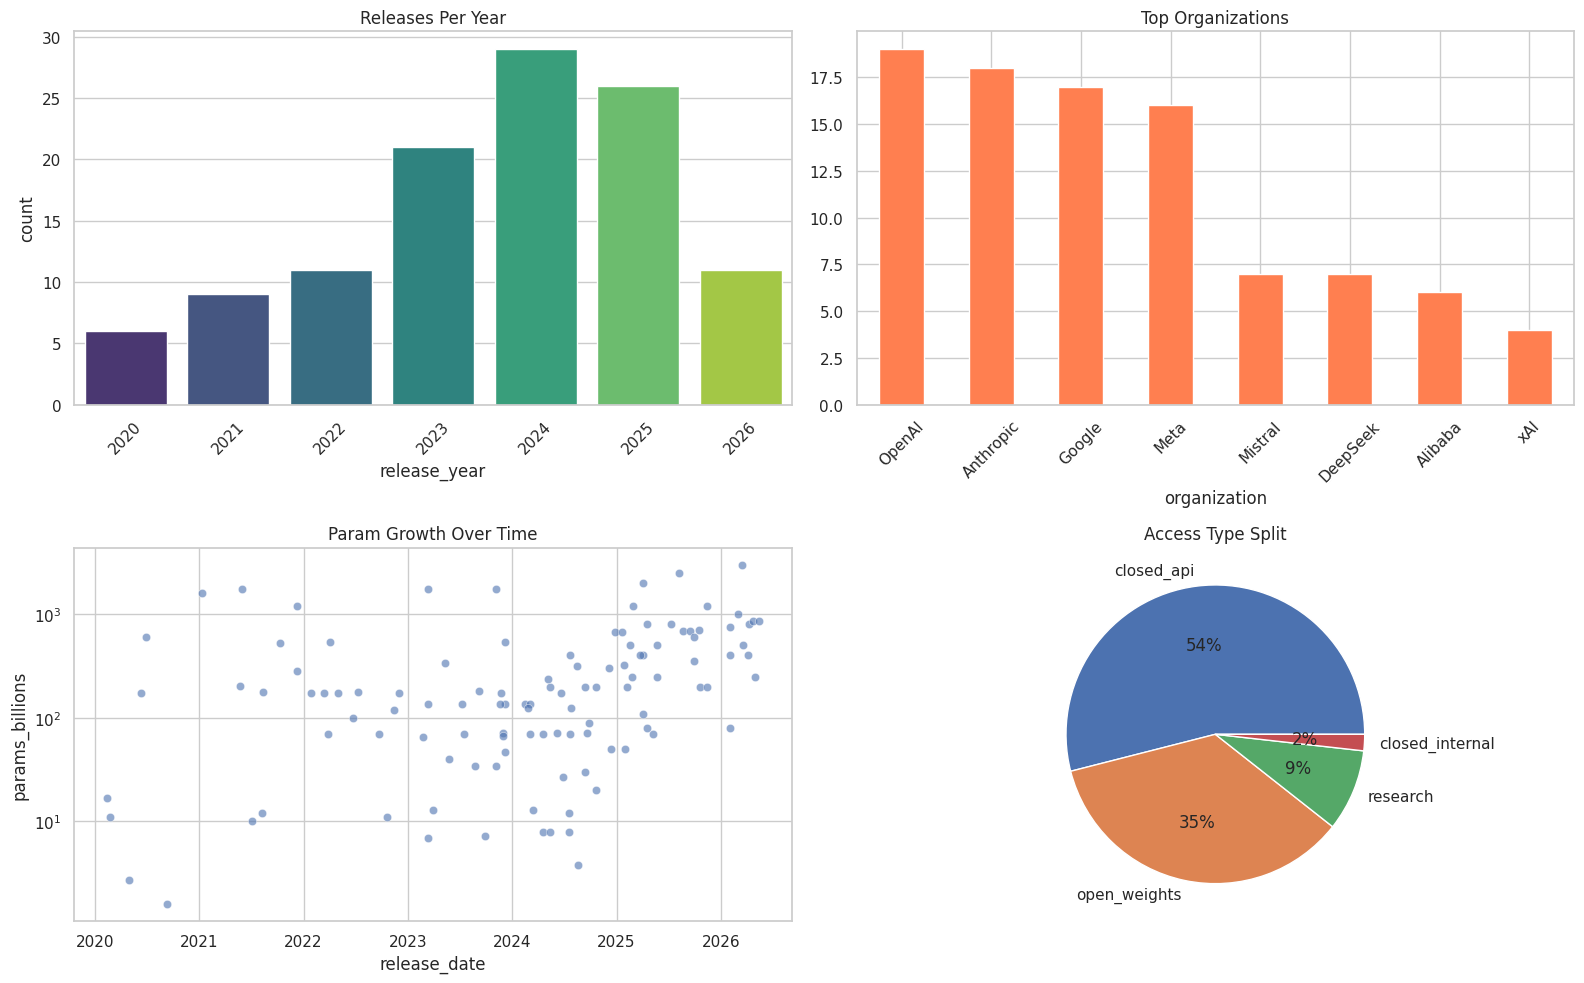

Saved cleaned_llm_master.csv: (113, 20)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Task 1 Complete: LLM dataset cleaned, merged, and visualized.


In [1]:
# ===================================================
# TASK 1: DATA CLEANING & VISUALIZATION
# Dataset: LLM Benchmarks & Capabilities (5 CSV files)
# ===================================================

# %% Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# %% Step 2: Upload All 5 CSV Files
from google.colab import files
print("Upload: models_catalog.csv, pricing_history.csv, capability_milestones.csv, compute_estimates.csv, benchmark_scores.csv")
uploaded = files.upload()

# %% Step 3: Load All Datasets
models = pd.read_csv("models_catalog.csv")
pricing = pd.read_csv("pricing_history.csv")
milestones = pd.read_csv("capability_milestones.csv")
compute = pd.read_csv("compute_estimates.csv")
benchmarks = pd.read_csv("benchmark_scores.csv")

print("Models:", models.shape)
print("Pricing:", pricing.shape)
print("Milestones:", milestones.shape)
print("Compute:", compute.shape)
print("Benchmarks:", benchmarks.shape)

models.head()

# %% Step 4: Convert Date Columns
models['release_date'] = pd.to_datetime(models['release_date'])
models['training_cutoff_date'] = pd.to_datetime(models['training_cutoff_date'])
compute['release_date'] = pd.to_datetime(compute['release_date'])
benchmarks['release_date'] = pd.to_datetime(benchmarks['release_date'])
milestones['date'] = pd.to_datetime(milestones['date'])
pricing['year_month'] = pd.to_datetime(pricing['year_month'])

# %% Step 5: Check Missing Values & Duplicates (all 5 files)
for name, d in [("models", models), ("pricing", pricing), ("milestones", milestones),
                ("compute", compute), ("benchmarks", benchmarks)]:
    print(f"\n{name}: missing={d.isnull().sum().sum()}, duplicates={d.duplicated().sum()}")

# %% Step 6: Drop Duplicates (safety net even if none found)
models = models.drop_duplicates()
pricing = pricing.drop_duplicates()
milestones = milestones.drop_duplicates()
compute = compute.drop_duplicates()
benchmarks = benchmarks.drop_duplicates()

# %% Step 7: Merge Models + Compute on model_id
master = models.merge(
    compute[['model_id', 'params_billions', 'tokens_trained_billions', 'training_flops',
             'gpu_hours_h100_equiv', 'training_cost_usd_est', 'energy_mwh', 'co2_tons_est']],
    on='model_id', how='left', suffixes=('', '_compute')
)
print("Master shape after merging compute:", master.shape)
master.head()

# %% Step 8: Outlier Detection - Training Cost & Params (IQR Method)
def detect_outliers_iqr(data, col):
    Q1, Q3 = data[col].quantile(0.25), data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return data[(data[col] < lower) | (data[col] > upper)]

cost_outliers = detect_outliers_iqr(master.dropna(subset=['training_cost_usd_est']), 'training_cost_usd_est')
print(f"Models with outlier training cost: {len(cost_outliers)}")
print(cost_outliers[['model_name', 'training_cost_usd_est']].sort_values('training_cost_usd_est', ascending=False).head(10))

# %% Step 9: Boxplots - Spot Outliers Visually
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(y=master['params_billions'], ax=axes[0], color='steelblue')
axes[0].set_title("Params (Billions) - Outliers")
sns.boxplot(y=master['training_cost_usd_est'], ax=axes[1], color='salmon')
axes[1].set_title("Training Cost (USD) - Outliers")
sns.boxplot(y=master['context_window_k_tokens'], ax=axes[2], color='mediumseagreen')
axes[2].set_title("Context Window (K tokens) - Outliers")
plt.tight_layout()
plt.savefig("outlier_boxplots.png", dpi=300)
plt.show()

# %% Step 10: Models Released Per Year
plt.figure(figsize=(10, 6))
sns.countplot(data=models, x='release_year', palette='viridis')
plt.title("Number of LLMs Released Per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("releases_per_year.png", dpi=300)
plt.show()

# %% Step 11: Top Organizations by Model Count
plt.figure(figsize=(10, 6))
models['organization'].value_counts().head(10).plot(kind='bar', color='coral')
plt.title("Top 10 Organizations by Number of Models Released")
plt.ylabel("Model Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("top_orgs.png", dpi=300)
plt.show()

# %% Step 12: Parameter Growth Over Time (Log Scale)
plt.figure(figsize=(12, 6))
sns.scatterplot(data=models, x='release_date', y='params_billions', hue='organization', legend=False, alpha=0.7)
plt.yscale('log')
plt.title("Model Size (Params, Billions) Over Time — Log Scale")
plt.xlabel("Release Date")
plt.ylabel("Params (Billions, log scale)")
plt.tight_layout()
plt.savefig("params_growth.png", dpi=300)
plt.show()

# %% Step 13: Context Window Growth Over Time
plt.figure(figsize=(12, 6))
sns.scatterplot(data=models, x='release_date', y='context_window_k_tokens', alpha=0.7, color='purple')
plt.yscale('log')
plt.title("Context Window Size Over Time — Log Scale")
plt.xlabel("Release Date")
plt.ylabel("Context Window (K tokens, log scale)")
plt.tight_layout()
plt.savefig("context_growth.png", dpi=300)
plt.show()

# %% Step 14: Access Type & Modality Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models['access_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0])
axes[0].set_title("Access Type Distribution")
axes[0].set_ylabel("")
models['modality'].value_counts().plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title("Modality Distribution")
plt.tight_layout()
plt.savefig("access_modality.png", dpi=300)
plt.show()

# %% Step 15: Pricing Trend Over Time (Top 10 Most Recent Models)
recent_models = pricing.sort_values('year_month').drop_duplicates('model_name', keep='last').nlargest(10, 'year_month')['model_name']
pricing_subset = pricing[pricing['model_name'].isin(recent_models)]

plt.figure(figsize=(12, 6))
for name, grp in pricing_subset.groupby('model_name'):
    plt.plot(grp['year_month'], grp['blended_usd_per_1m_tokens'], marker='o', label=name)
plt.title("Blended Price ($/1M tokens) Over Time — Recent Models")
plt.xlabel("Month")
plt.ylabel("USD per 1M tokens")
plt.legend(fontsize=8, loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("pricing_trend.png", dpi=300)
plt.show()

# %% Step 16: Combined Cleaning + Viz Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(data=models, x='release_year', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title("Releases Per Year")
axes[0, 0].tick_params(axis='x', rotation=45)

models['organization'].value_counts().head(8).plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title("Top Organizations")
axes[0, 1].tick_params(axis='x', rotation=45)

sns.scatterplot(data=models, x='release_date', y='params_billions', ax=axes[1, 0], alpha=0.6)
axes[1, 0].set_yscale('log')
axes[1, 0].set_title("Param Growth Over Time")

models['access_type'].value_counts().plot(kind='pie', autopct='%1.0f%%', ax=axes[1, 1])
axes[1, 1].set_title("Access Type Split")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.savefig("dashboard.png", dpi=300)
plt.show()

# %% Step 17: Save Cleaned & Merged Dataset
master.to_csv("cleaned_llm_master.csv", index=False)
print("Saved cleaned_llm_master.csv:", master.shape)

# %% Step 18: Download Outputs
files.download("cleaned_llm_master.csv")
files.download("dashboard.png")
files.download("params_growth.png")
files.download("pricing_trend.png")

print("Task 1 Complete: LLM dataset cleaned, merged, and visualized.")